## Notebook for error propagation for EPS 88 - Guest lecture by Penny Wieser

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
## If you haven't used it before, pip install the package
# pip install uncertainties
# import Thermobar as pt

## Error propagation in quadrature ('the traditional way')

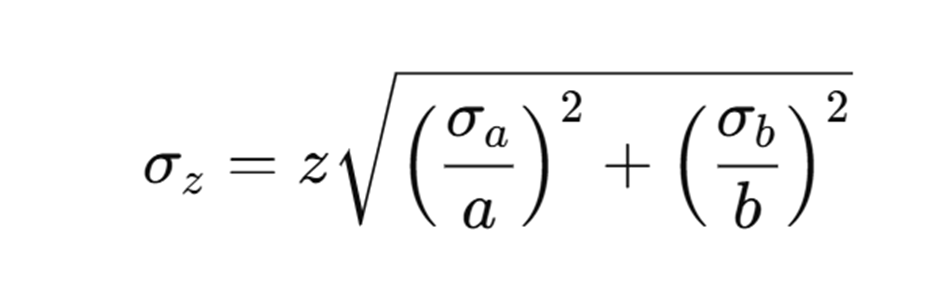

In [ ]:
a=100
a_err=5 # Absolute error
b=20
b_err=2 # Absolute error

Z=a/b
print('Z=', Z)

In [ ]:
sigma_z=Z* ((a_err/a)**2 + (b_err/b)**2 )**0.5
print('Z err=', sigma_z)

## Now lets use the uncertainties package

In [ ]:

from uncertainties import ufloat

# set up the varaibles, the syntax is the value, and then the error
a = ufloat(100, 5)  # a = 100 ± 5 # Absolute error
b = ufloat(20, 2)   # b = 20 ± 2 # Absolute error

# Perform the division
z = a / b

# This is the non ronuded value. 
print(f"Uncertainty: {z.std_dev}")

## Now try both methods for the pumice problem


In [ ]:
Mass= 1 # Say the pumice block weighed 1 kg. 
Mass_err_perc=1 #1 percent error based on the stage
volume_cm3=454.5 # Remember, balance your units out!
volume_err_cm3=10 # This is a absolute uncertainty. 

#### Students enter their working here
- Remember, check units
- Remember, think about whether the error is absolute or a percentage error, and what the function wants. 

**(10 points)** determine the uncertainty on the density of a pumice block using both quadrature and the uncertainties package.

In [ ]:
# Write code here to calculate density in kg/m3

## Lets use Monte-Carlo methods - Go back to lecture!


### Generating normal distributions

In [ ]:
# We can generate distributions in a variety of ways
Mean=5 # Mean of distribution
std_dev=1 # Std deviation of simulation
N=50 # Number of samples to make. 
test_normal=np.random.normal(Mean, std_dev, N)
# Lets plot and see what it looks like

plt.hist(test_normal) # how can we make it look more like a normal distribution?

### Generating uniform distributions

In [ ]:
# We can generate distributions in a variety of ways
Mean=5 # Mean of distribution
std_dev=1 # Std deviation of simulation
N=50 # Number of samples to make. 
test_uniform=np.random.uniform(Mean, std_dev, N)
# Lets plot and see what it looks like

plt.hist(test_uniform); # how can we make it look more like a normal distribution?

How can we make these two distributions/histograms look more like: (i) a true normal distribution; (ii) a true uniforma distribution? Try repeating the code above for each type of distribution but use a larger N. 

What difference does this make? Use the markdown code cell below to write your answer.
**(10 points)**

In [ ]:
# generate a normal distribution with a larger N

In [ ]:
# generate a uniform distribution with a larger N

## Random seeds can be really helpful
- Run the histogram above 3 times, you will get a slightly different distribution each time (especially if you run the example with a smaller N). You might not want this (so that your results are more reproducabile each time you open Python). We can do this by setting the ```random seed```

In [ ]:
# try running this cell multiple times

np.random.seed(42)
# We can generate distributions in a variety of ways
Mean=5 # Mean of distribution
std_dev=1 # Std deviation of simulation
N=50 # Number of samples to make. 
test_uniform=np.random.uniform(Mean, std_dev, N)
# Lets plot and see what it looks like

plt.hist(test_uniform)

#### Student exersize 

**(20 points)**
1) Use these functions to generate a normal error distributions for volume and mass in the pumice sample above (i.e., the prior distributions).
2) Use these distributions to calculate a distribution of calculated densities for the pumice (this is known as the posterior).
2) Make a 3 part subplot (1 row, 3 columns) that shows the prior distributions and the posterior distribution in panel a-c. Add axes labels and titles

In [ ]:
# Enter working here


##  Real data- Calculating the temperature of lava flows

In [ ]:
df_ML=pd.read_excel('data/EPS88_Glass_Data.xlsx')
df_ML.head()

## Temperature in lava flows can be calculated with a variety of equations
- Shea 2022 - 21.2 * MgO_Liq + 1017
- Helz 1987 - 20.1 * MgO_Liq + 1014
- Montrieth 1995 - 23.0 * MgO_Liq + 1012 



#### Student working

**(10 points)** Calculate temperatures with each equation, and plot temperature against MgO (use one plot to display the results from all equations). What type of error does the choice of model count as?


In [ ]:
# enter working here

**(20 points)** Now for a single equation (use the Shea equation), propagate the uncertainty in MgO. To do this we will use the following in formation:
- The uncertainty in MgO is given in the spreadsheet/DataFrame by the column Oxide % Sigma_MgO. 
- Assume the error is normally distributed (i.e., we can use the same functions as used above)
- For each sample, use N=500 duplicates.

Recreate the plot that you made above (comparison of different models) and add error bars to the results from the Shea equation, showing the spread in temperatures from variability in MgO. This provides a nice comparison of analytical error vs. model error. What types of error is each (random vs. systematic)

In [ ]:
## Student working



## Sometimes error bars arent the best way to visaulize data
- We are going to look at the outputs from propagating all oxides through methods to calculate pressure and temperature.
https://thermobar.readthedocs.io/en/latest/Examples/Error_propagation/Cpx_Liq_Thermobarometry_Error_prop.html
- I have recorded all the outputs - not just the mean and std in the loop - So each set of rows with the same value of Sample_ID_Liq is from a single glass

In [ ]:
Out_st_noise=pd.read_excel('data/EPS88_Glass_Data.xlsx', sheet_name='MC_outputs')

## Lets look at a histogram for the first two samples

In [ ]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "P_kbar_calc"], bins=50, ec='k', density = True)
ax1.annotate("Liquid 1-Cpx 1", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9)
ax2.hist(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==1, "P_kbar_calc"], bins=50, ec='k', density = True)
ax2.annotate("Liquid 3-Cpx 3", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9)

#ax2.set_xlim([0, 6])
ax1.set_xlabel('Pressure (kbar)')
ax2.set_xlabel('Pressure (kbar)')
ax1.set_ylabel('Probability Density')
ax2.set_ylabel('Probability Density')
fig.savefig('Manuscript_2CpxNoises.png', dpi=300, transparent=True)

#### Student Excersize 

**(10 points)** Add vertical lines onto these plots showing 
- The mean value
- The 16th quantile (look for a numpy function that can do this)
- The 84th Quantile
- the mean + 1 sigma, the mean - 1 sigma. 

In [ ]:
# enter working here

#### Student Exercize 

**(5 points)** Plot a conventional errorbar for each sample in PT space (e.g. error in x, error in y)

In [ ]:
# this is how to use the errorbar function
plt.errorbar(x=5, 
             y=5, 
             xerr=2, 
             yerr=1, 
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k')

In [ ]:
# Enter working here

#### Student exersize 

**(5 points)** choose a single sample and plot the P-T results from this sample to see if the errorbars provide a good approximation of the true error.

In [ ]:
#enter working here

## Now lets see another way of plotting this - and use error ellipses
Function is from here

https://matplotlib.org/stable/gallery/statistics/confidence_ellipse.html


In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The Axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

In [ ]:
# 
import Thermobar as pt

fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))

# you have to plot something on the axis before you try to add the confidence intervals
for sam in Out_st_noise['Sample_ID_Liq'].unique():
    Calc_PT_16=Out_st_noise.loc[Out_st_noise['Sample_ID_Liq']==sam].reset_index(drop=True)


    ax1.errorbar(np.nanmean(Calc_PT_16['T_K_calc']), 
             np.nanmean(Calc_PT_16['P_kbar_calc']), 
             xerr=np.nanstd(Calc_PT_16['T_K_calc']), 
             yerr=np.nanstd(Calc_PT_16['P_kbar_calc']), 
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k')

ax1.plot(
         Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "T_K_calc"],  
         Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "P_kbar_calc"],  
         '.k', alpha=0.01)
    




for sam in Out_st_noise['Sample_ID_Liq'].unique():
    
    Calc_PT_16=Out_st_noise.loc[Out_st_noise['Sample_ID_Liq']==sam].reset_index(drop=True)

    y=Calc_PT_16['P_kbar_calc'].loc[Calc_PT_16['P_kbar_calc']>-10].values
    x=Calc_PT_16['T_K_calc'].loc[Calc_PT_16['P_kbar_calc']>-10].values
    if sam==Out_st_noise['Sample_ID_Liq'].unique()[0]:
        confidence_ellipse(x, y, ax1, n_std=1,
                    edgecolor='red', lw=0.5, alpha=0.8, label='1σ MC simulations')
        confidence_ellipse(x, y, ax1, n_std=2,
                    edgecolor='magenta', lw=0.5, alpha=0.8, label='2σ MC simulations')
    else:
        confidence_ellipse(x, y, ax1, n_std=1,
                    edgecolor='red', lw=0.5, alpha=0.8)
        confidence_ellipse(x, y, ax1, n_std=2,
                    edgecolor='m', lw=0.5, alpha=0.8)


        
    
    

ax1.set_xlabel('T (K)')
ax1.set_ylabel('P (kbar)')





ax1.legend()
ax1.set_title('Cpx-Liq Error bars vs. ellipses')

fig.savefig('confidence_intervals_vs_errorbars.png', dpi=200)